In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Load the feature matrix and labels we just generated
X = np.load("X_raw.npy")
Y = np.load("Y_raw.npy")

print(f"Loaded X with shape: {X.shape}")
print(f"Loaded Y with shape: {Y.shape}")

# Show how many samples we have for each gesture
unique_classes, counts = np.unique(Y, return_counts=True)
print("\nClass Distribution:")
for cls, count in zip(unique_classes, counts):
    print(f"  {cls}: {count} samples")

Loaded X with shape: (50, 78)
Loaded Y with shape: (50,)

Class Distribution:
  m: 10 samples
  push: 10 samples
  pushpull: 10 samples
  star: 10 samples
  triangle: 10 samples


In [3]:
# 1. Convert text labels ('push', 'star', etc.) into numbers (0, 1, 2...)
label_encoder = LabelEncoder()
Y_encoded = label_encoder.fit_transform(Y)

# 2. Split into Training (80%) and Testing (20%)
# stratify=Y_encoded ensures we get an even mix of all gestures in the test set
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y_encoded, test_size=0.2, random_state=42, stratify=Y_encoded
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 40
Testing samples:  10


In [4]:
# 3. Scale the features (CRITICAL for SVMs)
# This forces every feature column to have a mean of 0 and standard deviation of 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Only transform the test set to prevent data leakage

# 4. Initialize and Train the SVM
# We use an RBF (Radial Basis Function) kernel, which is excellent for non-linear sensor data
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

print("Training SVM...")
svm_model.fit(X_train_scaled, Y_train)
print("Training complete!")

Training SVM...
Training complete!


🏆 Raw Signal Baseline Accuracy: 90.00%

Classification Report:
              precision    recall  f1-score   support

           m       1.00      1.00      1.00         2
        push       0.67      1.00      0.80         2
    pushpull       1.00      1.00      1.00         2
        star       1.00      1.00      1.00         2
    triangle       1.00      0.50      0.67         2

    accuracy                           0.90        10
   macro avg       0.93      0.90      0.89        10
weighted avg       0.93      0.90      0.89        10



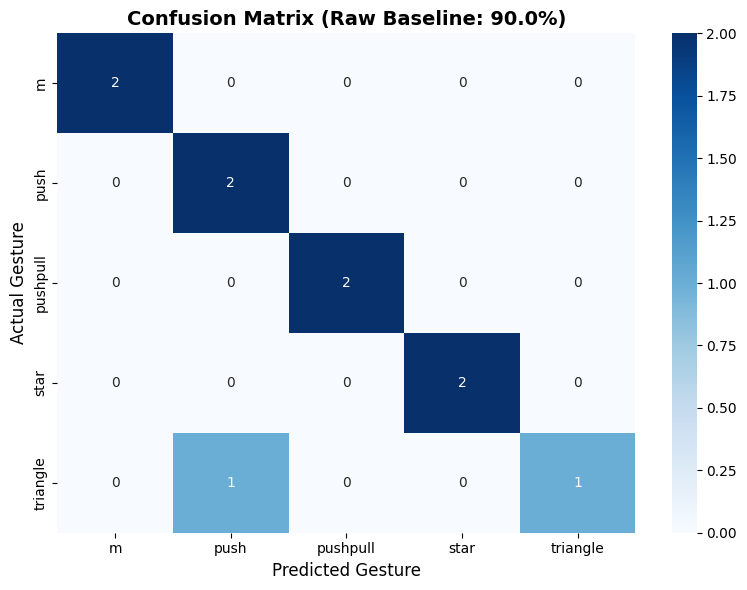

In [5]:
# 5. Make predictions on the unseen test set
Y_pred = svm_model.predict(X_test_scaled)

# Calculate Accuracy
accuracy = accuracy_score(Y_test, Y_pred)
print(f"🏆 Raw Signal Baseline Accuracy: {accuracy * 100:.2f}%\n")

# Print detailed metrics
print("Classification Report:")
print(classification_report(Y_test, Y_pred, target_names=label_encoder.classes_))

# 6. Plot a Confusion Matrix to see exactly which gestures confused the model
cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title(f"Confusion Matrix (Raw Baseline: {accuracy * 100:.1f}%)", fontsize=14, fontweight='bold')
plt.ylabel('Actual Gesture', fontsize=12)
plt.xlabel('Predicted Gesture', fontsize=12)
plt.tight_layout()
plt.show()

---

In [17]:
import glob
import os
from build_raw_dataset import process_file_raw

# Pick one of your older folders from your directory tree
TEST_DIR = "samples-good-4-30-morning" # Change to "samples-wo_sec" if you prefer
# TEST_DIR = "samples-wo_sec"
# TEST_DIR = "samples-old"
test_files = glob.glob(os.path.join(TEST_DIR, "*.rtcm"))

X_unseen = []
Y_unseen = []

print(f"Processing {len(test_files)} unseen files from '{TEST_DIR}'...")

for f in test_files:
    label = os.path.basename(f).split('-')[0]
    
    # Process the file using the exact same raw pipeline
    features = process_file_raw(f)
    if features is not None:
        X_unseen.append(features)
        Y_unseen.append(label)

X_unseen = np.array(X_unseen)
Y_unseen = np.array(Y_unseen)

print(f"Successfully extracted features for {len(X_unseen)} unseen samples.")

Processing 3 unseen files from 'samples-good-4-30-morning'...
Successfully extracted features for 3 unseen samples.


In [18]:
# Filter out any labels the model hasn't seen before (just in case)
valid_indices = [i for i, label in enumerate(Y_unseen) if label in label_encoder.classes_]
X_unseen_valid = X_unseen[valid_indices]
Y_unseen_valid = Y_unseen[valid_indices]

if len(X_unseen_valid) > 0:
    print(f"Testing on {len(X_unseen_valid)} valid samples...")

    # 1. Scale the unseen data using the ALREADY TRAINED scaler
    X_unseen_scaled = scaler.transform(X_unseen_valid)
    
    # 2. Encode the true labels
    Y_unseen_encoded = label_encoder.transform(Y_unseen_valid)
    
    # 3. Make Predictions
    Y_unseen_pred = svm_model.predict(X_unseen_scaled)
    
    # 4. Results
    unseen_accuracy = accuracy_score(Y_unseen_encoded, Y_unseen_pred)
    print(f"\n🚨 Unseen Data Accuracy: {unseen_accuracy * 100:.2f}%")
    
    print("\nActual vs Predicted:")
    for actual, pred in zip(Y_unseen_valid, label_encoder.inverse_transform(Y_unseen_pred)):
        marker = "✅" if actual == pred else "❌"
        print(f"{marker} Actual: {actual:<10} | Predicted: {pred}")
else:
    print("No valid samples found that match the trained gesture classes.")

Testing on 3 valid samples...

🚨 Unseen Data Accuracy: 100.00%

Actual vs Predicted:
✅ Actual: push       | Predicted: push
✅ Actual: push       | Predicted: push
✅ Actual: push       | Predicted: push


---